In [31]:
import torch
import torch.nn as nn
import numpy as np
from model import LSTMClassifier

In [32]:
def predict(model, df, feature_cols, window=60, device="cpu"):
    """
    df: DataFrame с уже посчитанными фичами (те же, что при обучении!)
    Возвращает предсказание для ПОСЛЕДНЕГО окна в df
    """
    model.eval()
    model.to(device)
    
    features = df[feature_cols].values.astype(np.float32)
    
    if len(features) < window:
        raise ValueError(f"Недостаточно данных: нужно минимум {window} свечей, получено {len(features)}")
    
    x = features[-window:]  # last window
    
    if np.isnan(x).any() or np.isinf(x).any():
        raise ValueError(f"NaN/Inf в входных данных! NaN count: {np.isnan(x).sum()}, Inf count: {np.isinf(x).sum()}")
    
    x_tensor = torch.tensor(x).unsqueeze(0).to(device)  # batch dimension -> (1, window, n_features)
    
    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1)
        pred_class = probs.argmax(dim=1).item()
    
    class_names = {0: "down", 1: "flat", 2: "up"}
    return {
        "prediction": class_names[pred_class],
        "probabilities": {
            "down": probs[0][0].item(),
            "flat": probs[0][1].item(),
            "up": probs[0][2].item()
        }
    }

In [33]:
import pandas as pd
from model import prepare_features_and_labels, feature_cols

# нужно заново создать модель с ТЕМИ ЖЕ параметрами архитектуры
model = LSTMClassifier(n_features=5, hidden_size=64, num_layers=2, num_classes=3)
model.load_state_dict(torch.load("models/lstm_0046_23.pt", map_location="cpu"))
model.eval()  # важно! переключает dropout/batchnorm в режим инференса

LSTMClassifier(
  (lstm): LSTM(5, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)

In [ ]:
from dataWorker import *
from datetime import datetime
# loading real data for test
start,end,duration,test_df = getRandomIntervalData('BTCUSDT', 120, normalize=True)
test_df = prepare_features_and_labels(test_df, horizon=5, flat_threshold=0.001)  # те же фичи!
print(f"Selected interval from {datetime.fromtimestamp(start//1000)} to {datetime.fromtimestamp(end//1000)}")

Interval from 2026-03-10 13:00:00 to 2026-03-10 15:00:00


In [35]:
result = predict(model, test_df, feature_cols, window=5)
print(result)

{'prediction': 'down', 'probabilities': {'down': 0.9952278137207031, 'flat': 0.00025508072576485574, 'up': 0.004517077933996916}}


win 133.8 points


Text(0.5, 1.0, 'Prediction Window')

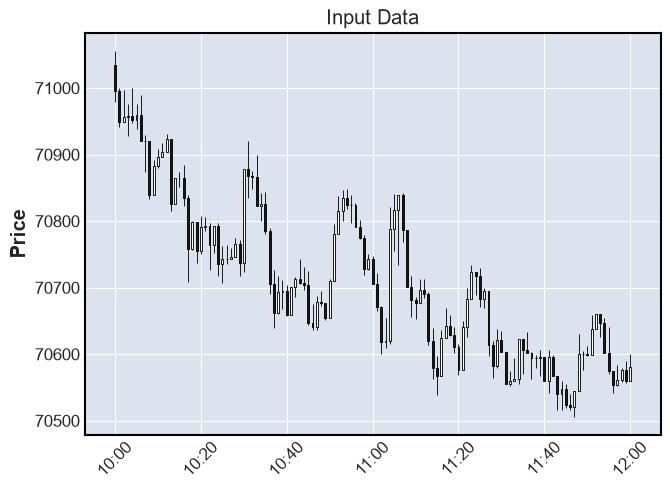

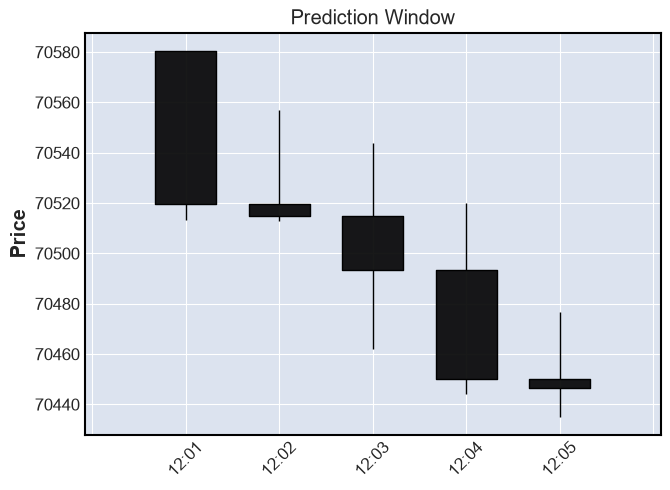

In [ ]:
from dataWorker import getOHLC
import mplfinance as mpf

df_plot = getOHLC('BTCUSDT', start, end)
df_plot = df_plot.set_index("timestamp")
df_final = getOHLC('BTCUSDT', (end//1000+60)*1000,(end//1000+60*5)*1000)
df_final = df_final.set_index("timestamp")

open_price = float(df_final.iloc[0]['open'])
close_price = float(df_final.iloc[4]['close'])

profit = round(close_price - open_price, 3)
if result.get('prediction') == 'down':
    if profit < 0: print(f'win {abs(profit)} points')
    else: print(f'loss {abs(profit)} points')
if result.get('prediction') == 'up':
    if profit > 0: print(f'win {abs(profit)} points')
    else: print(f'loss {abs(profit)} points')

# plotting
fig, ax = mpf.plot(df_plot, type='candle',returnfig=True)
ax[0].set_title('Input Data')
fig,ax = mpf.plot(df_final, type='candle',returnfig=True)
ax[0].set_title('Prediction Window')